# Email Spam Detection System Using Machine Learning and Natural Language Processing (NLP)

# Developed by DEEPAK.M AI Generalist iPEC Solutions Private Limited Bangalore
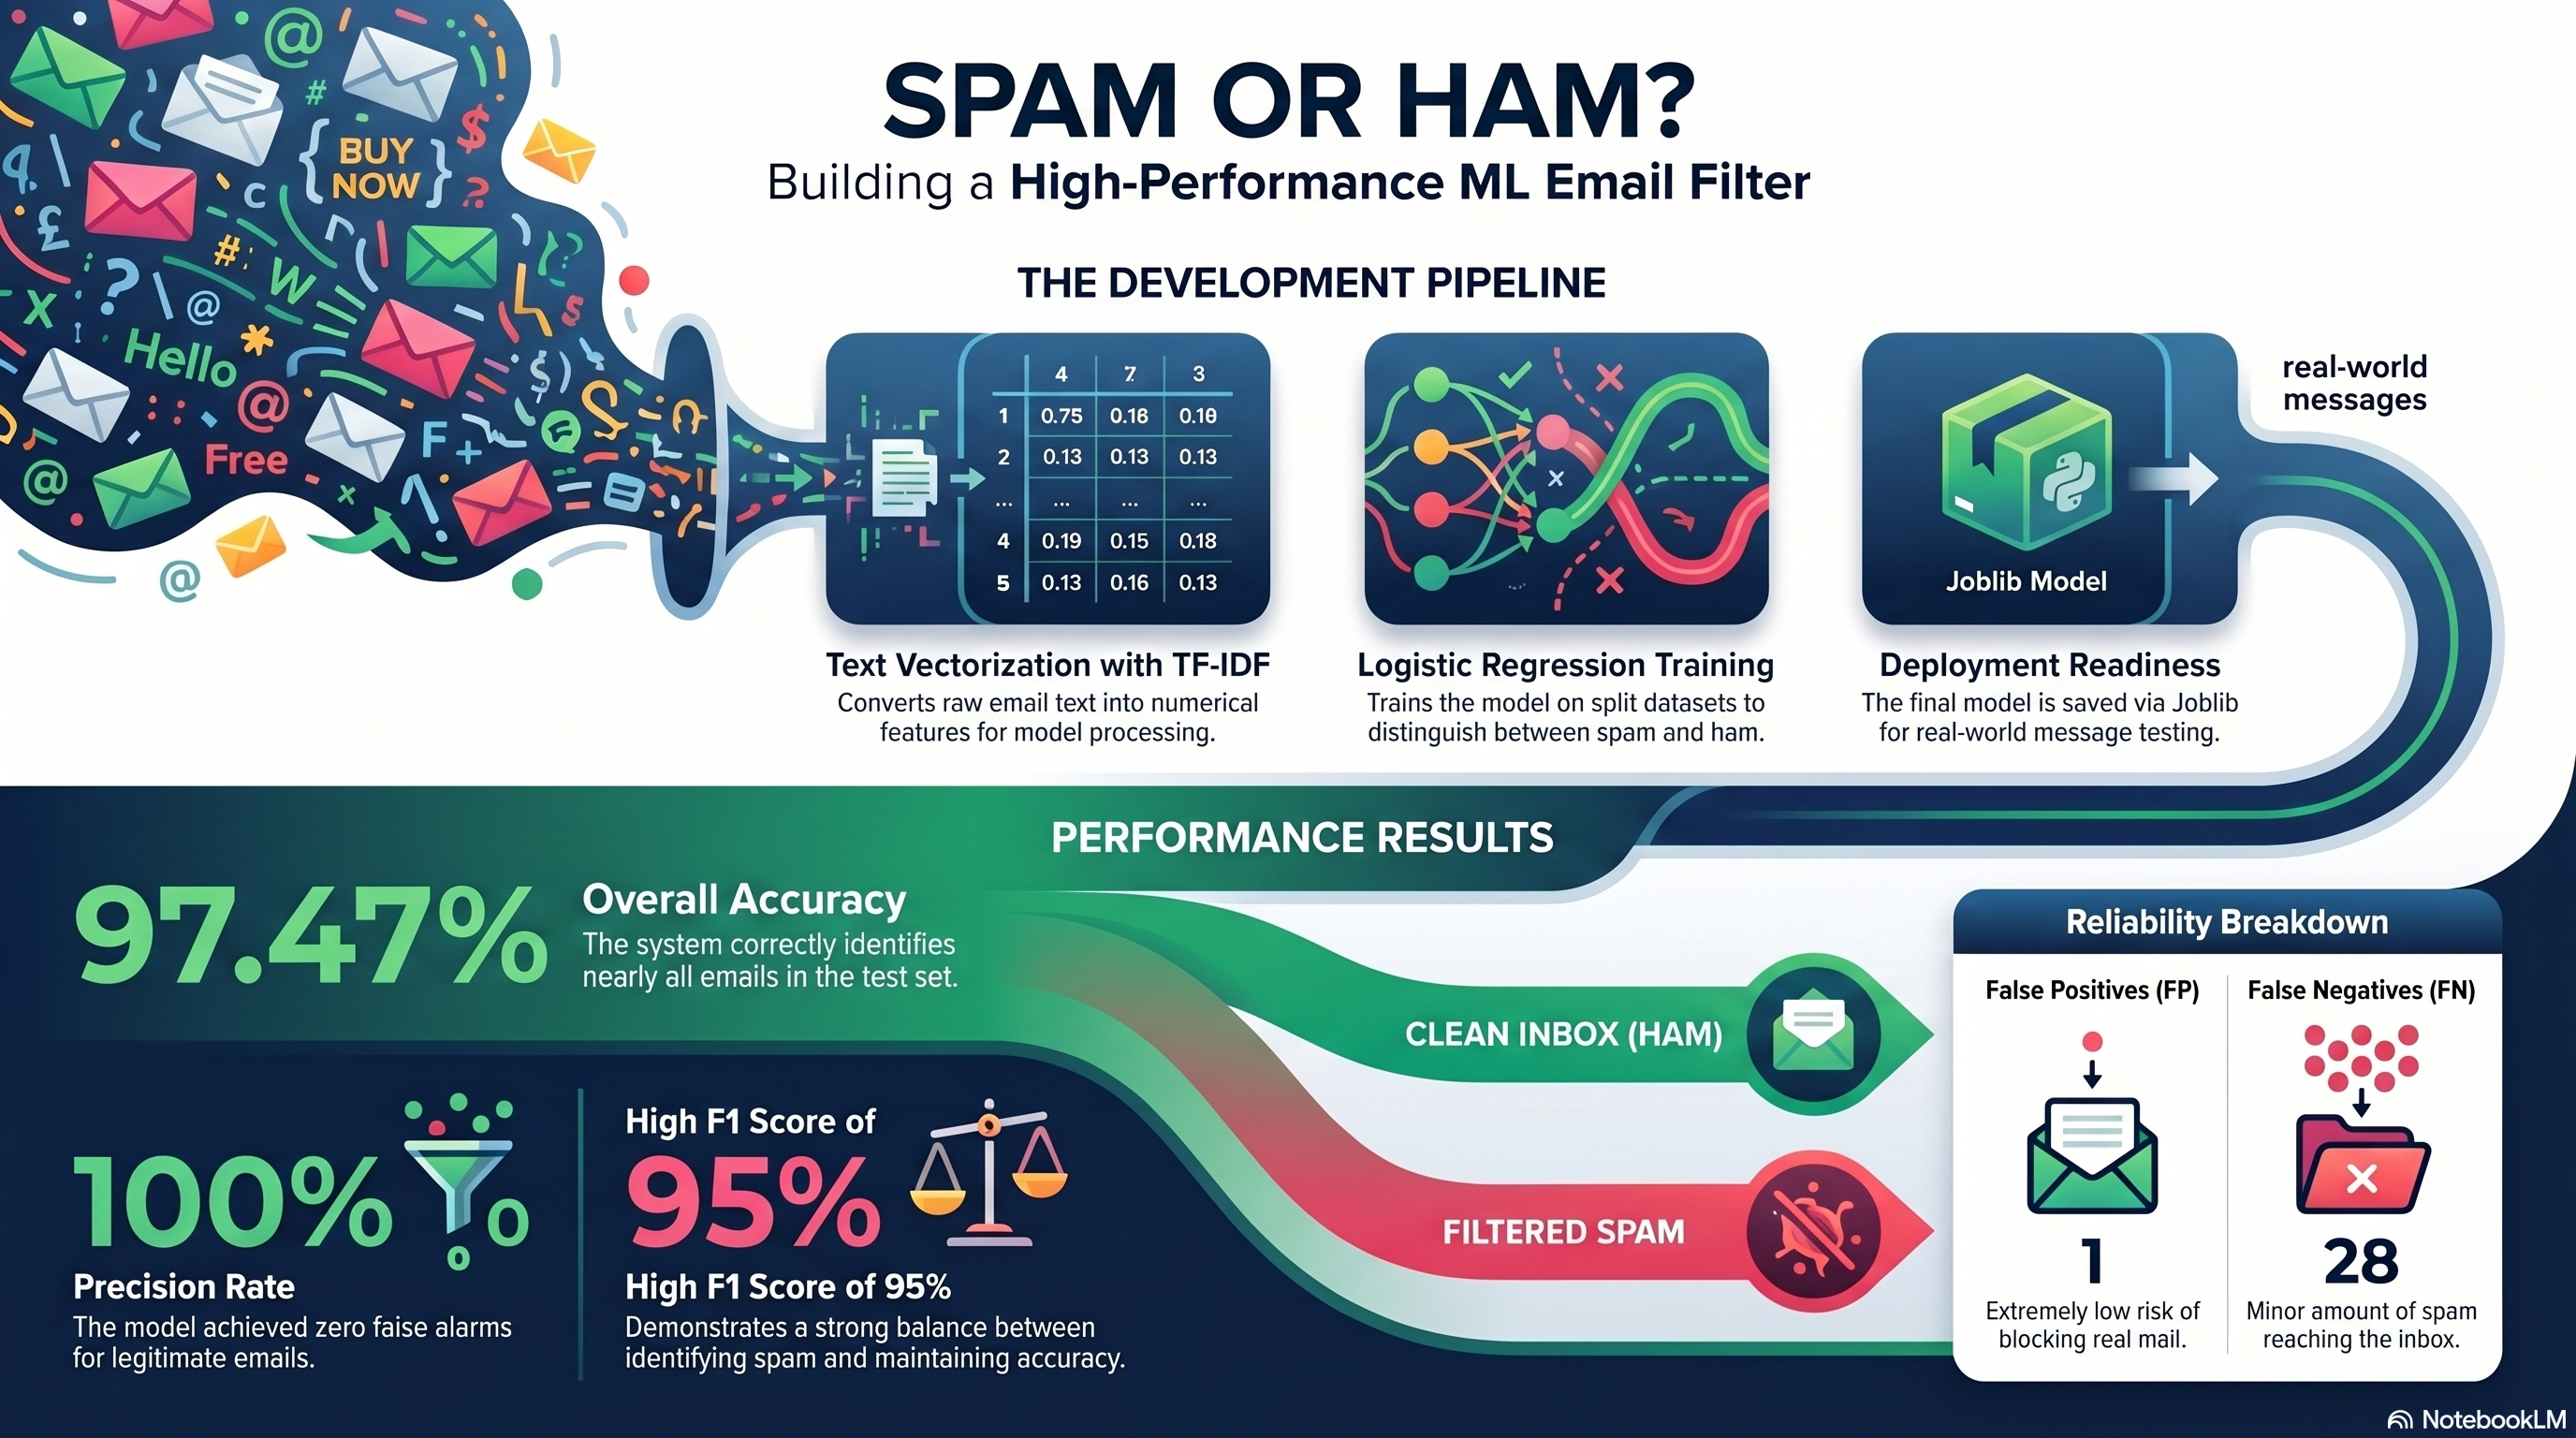

# 1.Load Dataset

In [28]:
import pandas as pd
df = pd.read_csv("emails_dataset.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


# 2.View Data

In [29]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


(5728, 2)

# 3.Check Missing Values

In [30]:
df.isnull().sum()

text    0
spam    0
dtype: int64

# 4.Check Spam Distribution

In [31]:
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

# 5.Split Features and Target

In [32]:
X = df['text']
y = df['spam']

# 6.Convert Text to Numbers

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

# 7.Train Test Split

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 8.Train Model

In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# 9.Make Predictions

In [36]:
y_pred = model.predict(X_test)

# 10.Confusion Matrix

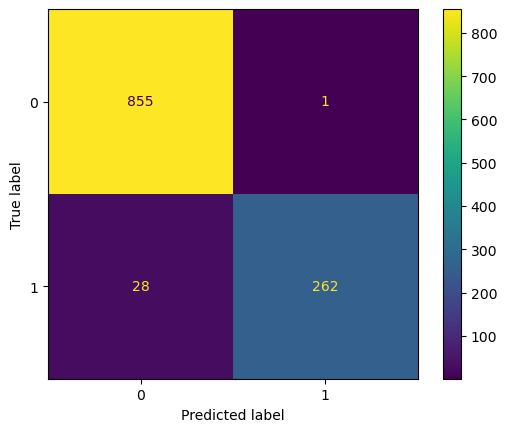

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

# 11.Classification Report

In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       856
           1       1.00      0.90      0.95       290

    accuracy                           0.97      1146
   macro avg       0.98      0.95      0.97      1146
weighted avg       0.98      0.97      0.97      1146



# 12.Check Accuracy

In [52]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.974694589877836


# 13.Save the Model

In [53]:
import joblib
joblib.dump(model, "spam_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

# 14.Test New Messages

In [55]:
message = ["Congratulations! You won a free prize. Call now!"]
message_tfidf = vectorizer.transform(message)
prediction = model.predict(message_tfidf)
print("Spam" if prediction[0] == 1 else "Ham")

Spam


In [60]:
test_messages = [
    "Hi Mom, I reached home safely.",
    "Win a free laptop today!",
    "Can you send me the notes?",
    "Congratulations, you won a cash reward.",
    "Meeting starts at 10 AM tomorrow.",
    "Claim your prize now by clicking this link.",
    "Don't forget to bring your ID card.",
    "You have been selected for a free gift."
]

for msg in test_messages:
    msg_tfidf = vectorizer.transform([msg])
    pred = model.predict(msg_tfidf)[0]

    print(f"Message: {msg}")
    print("Prediction:", "Spam" if pred == 1 else "Ham")
    print("-" * 50)

Message: Hi Mom, I reached home safely.
Prediction: Ham
--------------------------------------------------
Message: Win a free laptop today!
Prediction: Spam
--------------------------------------------------
Message: Can you send me the notes?
Prediction: Ham
--------------------------------------------------
Message: Congratulations, you won a cash reward.
Prediction: Ham
--------------------------------------------------
Message: Meeting starts at 10 AM tomorrow.
Prediction: Ham
--------------------------------------------------
Message: Claim your prize now by clicking this link.
Prediction: Spam
--------------------------------------------------
Message: Don't forget to bring your ID card.
Prediction: Spam
--------------------------------------------------
Message: You have been selected for a free gift.
Prediction: Spam
--------------------------------------------------


In [61]:
real_spam = [
    "You have won a lottery of Rs. 10,00,000. Call now.",
    "Free entry in a weekly competition. Text WIN to 12345.",
    "URGENT! Your bank account will be blocked. Verify now.",
    "Congratulations! You are selected for a free smartphone.",
    "Click here to receive your reward immediately."
]
for msg in test_messages:
    msg_tfidf = vectorizer.transform([msg])
    pred = model.predict(msg_tfidf)[0]

    print(f"Message: {msg}")
    print("Prediction:", "Spam" if pred == 1 else "Ham")
    print("-" * 50)

Message: Hi Mom, I reached home safely.
Prediction: Ham
--------------------------------------------------
Message: Win a free laptop today!
Prediction: Spam
--------------------------------------------------
Message: Can you send me the notes?
Prediction: Ham
--------------------------------------------------
Message: Congratulations, you won a cash reward.
Prediction: Ham
--------------------------------------------------
Message: Meeting starts at 10 AM tomorrow.
Prediction: Ham
--------------------------------------------------
Message: Claim your prize now by clicking this link.
Prediction: Spam
--------------------------------------------------
Message: Don't forget to bring your ID card.
Prediction: Spam
--------------------------------------------------
Message: You have been selected for a free gift.
Prediction: Spam
--------------------------------------------------
